In [1]:
#System Check

spark.conf.set("spark.sql.shuffle.partitions", "4")

print("Spark Version:", spark.version)
print("Spark Master:", spark.sparkContext.master)
print("Cassandra Host:", spark.conf.get("spark.cassandra.connection.host", "nicht gesetzt"))

spark.sql("SELECT 1 AS ok").show()

Spark Version: 3.5.0
Spark Master: spark://bd-1:7077
Cassandra Host: bd-2


+---+
| ok|
+---+
|  1|
+---+



In [2]:
import time
import matplotlib.pyplot as plt

from IPython.display import clear_output
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

16:45:59.623 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 0 on 0.0.0.0: Executor heartbeat timed out after 172150 ms
16:45:59.568 [dispatcher-BlockManagerMaster] ERROR org.apache.spark.rpc.netty.Inbox - Ignoring error
java.lang.AssertionError: assertion failed: BlockManager re-registration shouldn't succeed when the executor is lost
	at scala.Predef$.assert(Predef.scala:223) ~[scala-library-2.12.18.jar:?]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$register(BlockManagerMasterEndpoint.scala:727) ~[spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.storage.BlockManagerMasterEndpoint$$anonfun$receiveAndReply$1.applyOrElse(BlockManagerMasterEndpoint.scala:133) ~[spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:103) [spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213) [s

In [3]:

raw_kafka_df = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "bd-1:9092")
    .option("subscribe", "sensor.barometer")
    .option("startingOffsets", "earliest")
    .load()
)

raw_kafka_df.printSchema()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



In [4]:
message_schema = StructType([
    StructField("userId", StringType(), True),
    StructField("deviceId", StringType(), True),
    StructField("walkId", StringType(), True),
    StructField("sensorType", StringType(), True),
    StructField("timestamp", DoubleType(), True),
    StructField("data", StructType([
        StructField("timeSeconds", DoubleType(), True),
        StructField("pressureHpa", DoubleType(), True),
    ]), True),
])

barometer_df = (
    raw_kafka_df
    .select(
        F.col("topic"),
        F.col("partition"),
        F.col("offset"),
        F.col("timestamp").alias("kafkaTimestamp"),
        F.col("key").cast("string").alias("messageKey"),
        F.col("value").cast("string").alias("jsonValue")
    )
    .withColumn("json", F.from_json(F.col("jsonValue"), message_schema))
    .select(
        "topic",
        "partition",
        "offset",
        "kafkaTimestamp",
        "messageKey",
        "jsonValue",
        F.col("json.userId").alias("userId"),
        F.col("json.deviceId").alias("deviceId"),
        F.col("json.walkId").alias("walkId"),
        F.col("json.sensorType").alias("sensorType"),
        F.to_timestamp(F.from_unixtime(F.col("json.timestamp"))).alias("eventTime"),
        F.col("json.data.timeSeconds").alias("timeSeconds"),
        F.col("json.data.pressureHpa").alias("pressureHpa")
    )
)

barometer_df.printSchema()

root
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- kafkaTimestamp: timestamp (nullable = true)
 |-- messageKey: string (nullable = true)
 |-- jsonValue: string (nullable = true)
 |-- userId: string (nullable = true)
 |-- deviceId: string (nullable = true)
 |-- walkId: string (nullable = true)
 |-- sensorType: string (nullable = true)
 |-- eventTime: timestamp (nullable = true)
 |-- timeSeconds: double (nullable = true)
 |-- pressureHpa: double (nullable = true)



In [5]:
windowed_barometer_df = (
    barometer_df
    .withWatermark("eventTime", "1 minute")
    .groupBy(
        F.window(F.col("eventTime"), "10 seconds", "5 seconds"),
        F.col("walkId"),
        F.col("deviceId"),
        F.col("sensorType")
    )
    .agg(
        F.count("*").alias("measurementCount"),
        F.avg("pressureHpa").alias("avgPressureHpa"),
        F.min("pressureHpa").alias("minPressureHpa"),
        F.max("pressureHpa").alias("maxPressureHpa"),
        F.stddev("pressureHpa").alias("stddevPressureHpa")
    )
    .select(
        F.col("window.start").alias("windowStart"),
        F.col("window.end").alias("windowEnd"),
        "walkId",
        "deviceId",
        "sensorType",
        "measurementCount",
        "avgPressureHpa",
        "minPressureHpa",
        "maxPressureHpa",
        "stddevPressureHpa"
    )
)

windowed_barometer_df.printSchema()

root
 |-- windowStart: timestamp (nullable = true)
 |-- windowEnd: timestamp (nullable = true)
 |-- walkId: string (nullable = true)
 |-- deviceId: string (nullable = true)
 |-- sensorType: string (nullable = true)
 |-- measurementCount: long (nullable = false)
 |-- avgPressureHpa: double (nullable = true)
 |-- minPressureHpa: double (nullable = true)
 |-- maxPressureHpa: double (nullable = true)
 |-- stddevPressureHpa: double (nullable = true)



In [6]:
cassandra_result_df = (
    windowed_barometer_df
    .select(
        F.col("walkId").alias("walk_id"),
        F.col("deviceId").alias("device_id"),
        F.col("sensorType").alias("sensor_type"),
        F.col("windowStart").alias("window_start"),
        F.col("windowEnd").alias("window_end"),
        F.col("measurementCount").cast("long").alias("measurement_count"),
        F.col("avgPressureHpa").alias("avg_pressure_hpa"),
        F.col("minPressureHpa").alias("min_pressure_hpa"),
        F.col("maxPressureHpa").alias("max_pressure_hpa"),
        F.col("stddevPressureHpa").alias("stddev_pressure_hpa"),
        F.current_timestamp().alias("updated_at")
    )
)

cassandra_result_df.printSchema()

root
 |-- walk_id: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- sensor_type: string (nullable = true)
 |-- window_start: timestamp (nullable = true)
 |-- window_end: timestamp (nullable = true)
 |-- measurement_count: long (nullable = false)
 |-- avg_pressure_hpa: double (nullable = true)
 |-- min_pressure_hpa: double (nullable = true)
 |-- max_pressure_hpa: double (nullable = true)
 |-- stddev_pressure_hpa: double (nullable = true)
 |-- updated_at: timestamp (nullable = false)



In [7]:
def write_to_cassandra(batch_df, batch_id):
    print(f"Batch {batch_id}: schreibe nach Cassandra")

    (
        batch_df
        .write
        .format("org.apache.spark.sql.cassandra")
        .mode("append")
        .options(
            keyspace="sensor_cache",
            table="barometer_window_results"
        )
        .option("spark.cassandra.output.consistency.level", "ONE")
        .save()
    )

    print(f"Batch {batch_id}: erfolgreich nach Cassandra geschrieben")

In [8]:
#Startet Cassandra-Streaming-Write

cassandra_query = (
    cassandra_result_df
    .writeStream
    .foreachBatch(write_to_cassandra)
    .outputMode("update")
    .option("checkpointLocation", "hdfs://bd-1:9000/data/checkpoint/cassandra_barometer_result_cache")
    .trigger(processingTime="10 seconds")
    .start()
)

print("Cassandra Streaming Query gestartet.")

Cassandra Streaming Query gestartet.


In [9]:
print("Aktiv:", cassandra_query.isActive)
print("Status:", cassandra_query.status)
print("Exception:", cassandra_query.exception())
print("Last Progress:", cassandra_query.lastProgress)

Aktiv: True
Status: {'message': 'Initializing sources', 'isDataAvailable': False, 'isTriggerActive': False}
Exception: None
Last Progress: None


In [10]:
#Live Cassandra Ergebnisse
#Kann man auch über Terminal zeigen via Query

from pyspark.sql import functions as F

cached_results_df = (
    spark.read
    .format("org.apache.spark.sql.cassandra")
    .options(
        keyspace="sensor_cache",
        table="barometer_window_results"
    )
    .load()
)

filtered_cache_df = (
    cached_results_df
    .filter(F.col("walk_id") == "walk-2026-03-04-01")
    .filter(F.col("sensor_type") == "barometer")
    .filter(F.year(F.col("window_start")) == 2026)
    .select(
        "walk_id",
        "sensor_type",
        "window_start",
        "window_end",
        "measurement_count",
        "avg_pressure_hpa",
        "min_pressure_hpa",
        "max_pressure_hpa",
        "stddev_pressure_hpa"
    )
    .orderBy("window_start")
)

filtered_cache_df.show(20, truncate=False)

Batch 63: schreibe nach Cassandra


+------------------+-----------+-------------------+-------------------+-----------------+-----------------+----------------+----------------+---------------------+
|walk_id           |sensor_type|window_start       |window_end         |measurement_count|avg_pressure_hpa |min_pressure_hpa|max_pressure_hpa|stddev_pressure_hpa  |
+------------------+-----------+-------------------+-------------------+-----------------+-----------------+----------------+----------------+---------------------+
|walk-2026-03-04-01|barometer  |2026-05-30 11:32:45|2026-05-30 11:32:55|3                |958.2108815666667|958.2105255     |958.2112122     |3.440557561213712E-4 |
|walk-2026-03-04-01|barometer  |2026-05-30 11:32:50|2026-05-30 11:33:00|8                |958.2119655625   |958.2105255     |958.213501      |0.001216903440123325 |
|walk-2026-03-04-01|barometer  |2026-05-30 11:32:55|2026-05-30 11:33:05|5                |958.21261596     |958.210907      |958.213501      |0.0010593634541312539|
|walk-2026

Batch 63: erfolgreich nach Cassandra geschrieben


In [4]:
filtered_cache_df.select(
    F.min("window_start").alias("min_window_start"),
    F.max("window_start").alias("max_window_start"),
    F.count("*").alias("row_count")
).show(truncate=False)

filtered_cache_df.groupBy(F.to_date("window_start").alias("date")).count().orderBy("date").show(truncate=False)

+-------------------+-------------------+---------+
|min_window_start   |max_window_start   |row_count|
+-------------------+-------------------+---------+
|2026-05-30 11:32:45|2026-05-31 15:53:15|773      |
+-------------------+-------------------+---------+

+----------+-----+
|date      |count|
+----------+-----+
|2026-05-30|624  |
|2026-05-31|149  |
+----------+-----+



In [5]:
filtered_cache_df_day = (
    filtered_cache_df
    .filter(F.to_date(F.col("window_start")) == F.lit("2026-05-31"))
    .orderBy("window_start")
)

filtered_cache_df_day.show(20, truncate=False)

+------------------+-----------+-------------------+-------------------+-----------------+-----------------+----------------+----------------+---------------------+
|walk_id           |sensor_type|window_start       |window_end         |measurement_count|avg_pressure_hpa |min_pressure_hpa|max_pressure_hpa|stddev_pressure_hpa  |
+------------------+-----------+-------------------+-------------------+-----------------+-----------------+----------------+----------------+---------------------+
|walk-2026-03-04-01|barometer  |2026-05-31 15:34:35|2026-05-31 15:34:45|7                |958.2117462142858|958.2105255     |958.213501      |0.0011307530004546463|
|walk-2026-03-04-01|barometer  |2026-05-31 15:34:40|2026-05-31 15:34:50|17               |958.2128951117647|958.2105255     |958.2142639     |0.0013013213797934075|
|walk-2026-03-04-01|barometer  |2026-05-31 15:34:45|2026-05-31 15:34:55|20               |958.2121620249998|958.2097626     |958.2142639     |0.0017350804962731432|
|walk-2026

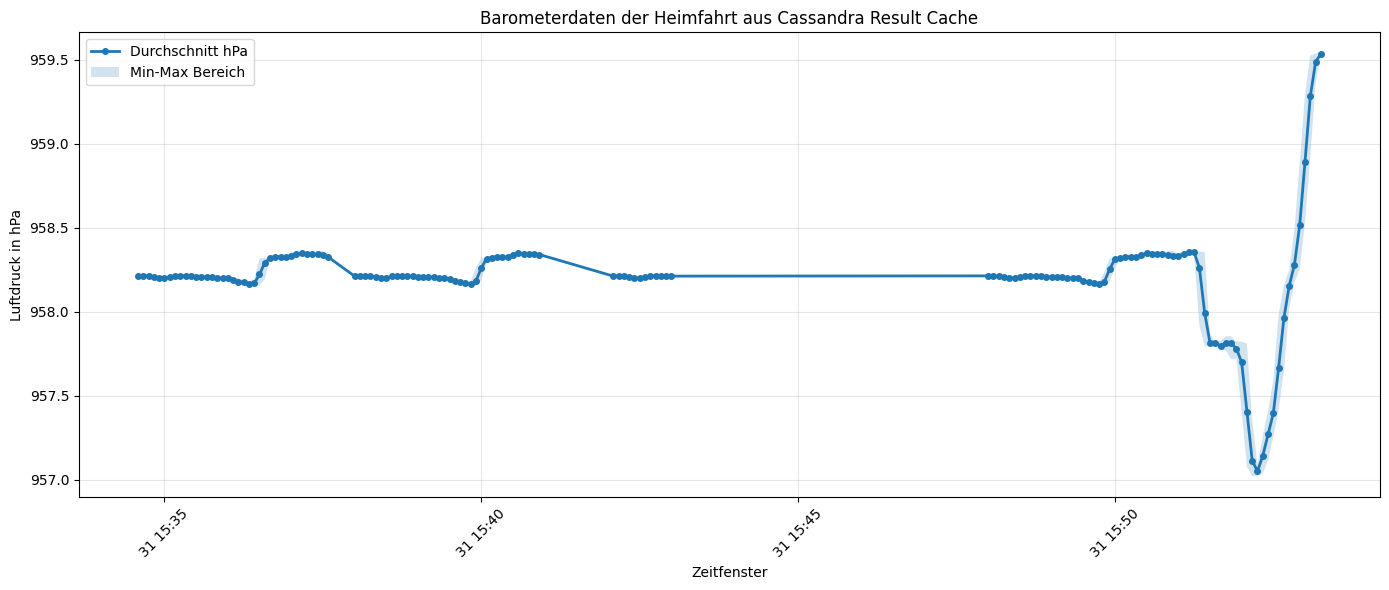

In [8]:
import matplotlib.pyplot as plt

pdf_cache = (
    filtered_cache_df_day
    .select(
        "window_start",
        "avg_pressure_hpa",
        "min_pressure_hpa",
        "max_pressure_hpa",
        "measurement_count"
    )
    .orderBy("window_start")
    .toPandas()
)

if pdf_cache.empty:
    print("Keine passenden Daten für diesen Tag gefunden.")
else:
    pdf_cache = pdf_cache.dropna(subset=["window_start", "avg_pressure_hpa"])
    pdf_cache = pdf_cache.sort_values("window_start")

    plt.figure(figsize=(14, 6))

    plt.plot(
        pdf_cache["window_start"],
        pdf_cache["avg_pressure_hpa"],
        marker="o",
        linewidth=2,
        markersize=4,
        label="Durchschnitt hPa"
    )

    plt.fill_between(
        pdf_cache["window_start"],
        pdf_cache["min_pressure_hpa"],
        pdf_cache["max_pressure_hpa"],
        alpha=0.2,
        label="Min-Max Bereich"
    )

    plt.xlabel("Zeitfenster")
    plt.ylabel("Luftdruck in hPa")
    plt.title("Barometerdaten der Heimfahrt aus Cassandra Result Cache")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()